
## 1. Introducere

### Setul de date 

Setul de date ** Pharmaceutical data both Machine learning & NLP ** este compus dintr-un fișier .csv care cuprinde informații despre 20000 de medicamente. Aceste informații sunt împărțite pe următoarele coloane:
- numele medicamentului
- categoria 
- condiția pentru care medicamentul este utilizat
- efecte secundare
- forma de administrare
- concentrația substanței active
- statusul prescripției
- fabricantul
- anul aprobării
- descrierea
- prețul
- statusul pe piață

Setul este preluat de pe platforma Kaggle și poate fi accesat la adresa: https://www.kaggle.com/datasets/sinananu/pharmaceutical-data-both-machine-learning-and-nlp

### Obiectivele proiectului

Proiectul reprezintă un sistem de recomandare de medicamente alternative pe baza asemănărilor dintre date. Astfel, primind ca input un medicament, va recomanda medicamente similare cu acesta, ținând cont de asemănarea indicațiilor și a concentrației.


Prima etapă va presupune implementarea a trei metode de Machine Learning pentru clasificare:
1. KNN (K-Nearest Neighbors) pentru recomandări
2. SVM pentru clasificarea pe categorii
3. Logistic Regression pentru predicții - dacă un medicament constituie o alternativă





## 2. Procesarea și prelucrarea datelor

### Citirea setului de date 

Se citește setul de date cu ajutorul Spark API astfel: se creează o sesiune Spark, se citește fișierul .csv în această schemă și apoi se modifică numele coloanelor astfel încât să nu conțină spații. Rezultatul citirii fișierului este o structură de date similară cu un tabel denumită data frame.

In [1]:
from pyspark.sql import SparkSession

# creare sesiune spark
spark = SparkSession.builder.appName("Recomandare medicamente").getOrCreate()

# citire set de date și obținere dataframe
source_data = spark.read.csv("pharma_1.csv", header=True)

# redenumire coloane
col_names = ['DrugName', 'DrugClass', 'Indication', 'SideEffects', 'DosageForm', 'DosageStrength', 'PrescriptionStatus', 
             'Manufacturer', 'ApprovalYear', 'Description', 'Price', 'MarketStatus']

source_data = source_data.toDF(*col_names)
source_data.printSchema()


root
 |-- DrugName: string (nullable = true)
 |-- DrugClass: string (nullable = true)
 |-- Indication: string (nullable = true)
 |-- SideEffects: string (nullable = true)
 |-- DosageForm: string (nullable = true)
 |-- DosageStrength: string (nullable = true)
 |-- PrescriptionStatus: string (nullable = true)
 |-- Manufacturer: string (nullable = true)
 |-- ApprovalYear: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- MarketStatus: string (nullable = true)



### Transformarea și curățarea datelor


Valorile de tip string din data frame sunt prelucrate prin eliminarea spațiilor de la începutul și finalul acestora și prin aducerea tuturor caracterelor la format lowercase. În plus, se execută formatări și la nivelul coloanelor care trebuie să conțină valori numerice.

In [2]:
from pyspark.sql.functions import col, lower, round, split, row_number, lit, regexp_replace, trim
from pyspark.sql.window import Window

# adăugare coloană ID
# normalizare date: transformare string-uri in lowercase, eliminare spatii goale de la inceput si final, eliminare spații din coloana efecte secundare
# formatare pret: 2 zecimale
# eliminare unitate de masura - concentratie
# înlocuire valori null pentru concentrație cu 0.0
window = Window.orderBy(lit(1))

formatted_data = source_data.withColumn('DrugID', row_number().over(window)).withColumn("DrugName", lower(trim(source_data.DrugName))).withColumn("DrugClass", lower(trim(source_data.DrugClass))) \
.withColumn("Indication", lower(trim(source_data.Indication))).withColumn("SideEffects", regexp_replace(lower(col("SideEffects")), r",\s*", ",")) \
.withColumn("DosageForm", lower(trim(source_data.DosageForm))).withColumn("PrescriptionStatus", lower(trim(source_data.PrescriptionStatus))) \
.withColumn("Manufacturer", lower(trim(source_data.Manufacturer))).withColumn("Description", lower(trim(source_data.Description))) \
.withColumn("MarketStatus", lower(trim(source_data.MarketStatus))).withColumn("Price", round(col("Price"), 2))\
.withColumn("DosageStrength", split(col("DosageStrength"), " ")[0].cast("int")).fillna({"DosageStrength": 0.0})

# creare liste de efecte secundare
formatted_data = formatted_data.withColumn("SideEffects", split(col("SideEffects"), ","))

formatted_data.show(5, truncate=False)

+---------+----------------+-----------------+------------------------------------+----------+--------------+------------------+------------+------------+---------------------------------------------+------+------------+------+
|DrugName |DrugClass       |Indication       |SideEffects                         |DosageForm|DosageStrength|PrescriptionStatus|Manufacturer|ApprovalYear|Description                                  |Price |MarketStatus|DrugID|
+---------+----------------+-----------------+------------------------------------+----------+--------------+------------------+------------+------------+---------------------------------------------+------+------------+------+
|drug-7690|antiviral       |wound cleaning   |[fatigue, drowsiness, stomach upset]|gel       |356           |prescription      |biosynth    |2021        |a antiviral used for wound cleaning.         |414.14|discontinued|1     |
|drug-2191|sedative        |anxiety reduction|[nausea]                            |injec

Următorul pas îl reprezintă crearea de rapoarte prin agregări și grupări de date.

Prin folosirea Dataframe API, se va rezolva umrătoarea cerință:
- să se afișeze primii 5 ani în care s-au aprobat cele mai multe mediamente

Prin folosirea Spark SQL, se va rezolva umrătoarea cerință:
- să se afișeze prețul mediu al medicamentelor încă active pe piață per categorie și fabricant

C:\Users\maria\AppData\Local\Temp\ipykernel_820\2452659060.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_years["ApprovalYear"], y=top_5_years["Number of drugs"], palette="summer")


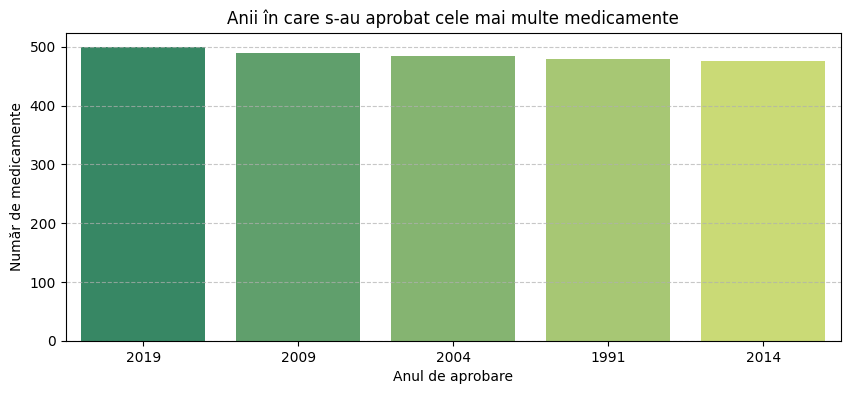

In [3]:
from pyspark.sql.functions import count
import matplotlib.pyplot as plt
import seaborn as sns

# cerinta 1 (Dataframes API) - primii 5 ani în care s-au aprobat cele mai multe medicamente
top_5_years = source_data.groupBy("ApprovalYear").agg(count("*").alias("Number of drugs")).orderBy(col("Number of drugs").desc()).limit(5)

# afișare date
# transformare data frame in pandas pentru plot
top_5_years = top_5_years.toPandas()

# creare diagramă
plt.figure(figsize=(10, 4))
plt.title("Anii în care s-au aprobat cele mai multe medicamente", fontsize=12)
plt.xlabel("Anul de aprobare", fontsize=10)
plt.ylabel("Număr de medicamente", fontsize=10)

sns.barplot(x=top_5_years["ApprovalYear"], y=top_5_years["Number of drugs"], palette="summer")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


C:\Users\maria\AppData\Local\Temp\ipykernel_820\825516922.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_prices["Manufacturer"], y=avg_prices["AVG Price"], palette="YlGn")


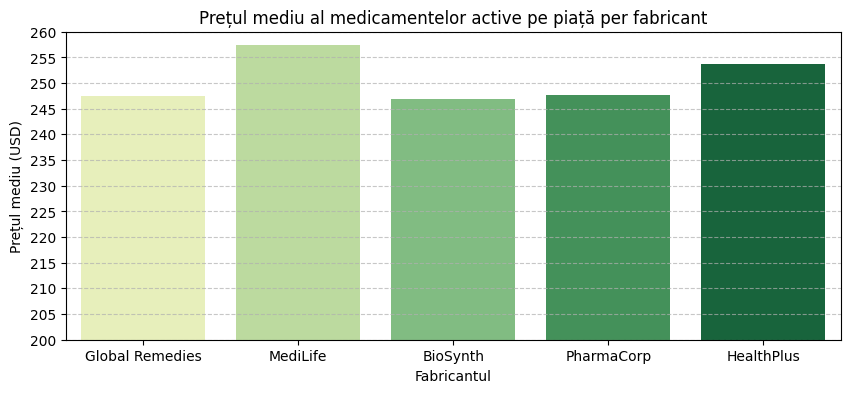

In [4]:
import numpy as np


# cerința 2 (Spark SQL) - prețul mediu al medicamentelor încă active pe piață per fabricant
source_data.createOrReplaceTempView("drugs")
avg_prices = spark.sql("""
    SELECT 
        Manufacturer,  
        ROUND(AVG(`Price`), 2) AS `AVG Price`
    FROM drugs
    WHERE `MarketStatus` = 'Active'
    GROUP BY Manufacturer
""")
avg_prices = avg_prices.toPandas()

plt.figure(figsize=(10, 4))
plt.ylim(200, 260)
plt.yticks(np.arange(200, 261, 5))

plt.title("Prețul mediu al medicamentelor active pe piață per fabricant", fontsize=12)
plt.xlabel("Fabricantul", fontsize=10)
plt.ylabel("Prețul mediu (USD)", fontsize=10)

sns.barplot(x=avg_prices["Manufacturer"], y=avg_prices["AVG Price"], palette="YlGn")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Metode de Machine Learning

Pentru a putea crea și antrena modele de clasificare folosite la construirea sistemelor de recomandări, se va împărți setul de date în 80% valori de antrenament și 20% valori de testare.


In [5]:

train_data, test_data = formatted_data.randomSplit(weights=[0.8,0.2], seed=60)
print("Dimensiunea setului de antrenament: ", train_data.count(), "\nDimensiunea setului de test: ", test_data.count())



Dimensiunea setului de antrenament:  16000 
Dimensiunea setului de test:  4000


### Metoda K-Means

Enunțul problemei:
Dându-se un medicament, să se recomande alternative la acesta, în funcție de indicații și dozaj.

Se va folosi metoda de Machine Learning K-Means, care grupează datele în K clustere pe baza asemănărilor dintre ele. Aceasta asignează aleator K centre pentru viitoarele clustere, apoi adaugă fiecare entitate în grupul al cărui centru este cel mai apropiat de aceasta. Centrele sunt apoi calculate ca fiind media elementelor din cluster și algoritmul se repetă pentru un număr dat de pași sau până nu se mai fac modificări. 



In [6]:
from pyspark.ml.feature import Tokenizer, VectorAssembler, HashingTF, IDF
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import random

# împărțire indicații în cuvinte (tokeni)
words_split = Tokenizer(inputCol='Indication', outputCol='IndicationWords')
tokenized_train_data = words_split.transform(train_data)
tokenized_test_data = words_split.transform(test_data)


# transformare cuvinte in valori numerice
hashing = HashingTF(inputCol='IndicationWords', outputCol='IndicationHash', numFeatures=1000)
hashed_train_data = hashing.transform(tokenized_train_data)
hashed_test_data = hashing.transform(tokenized_test_data)
idf = IDF(inputCol='IndicationHash', outputCol='IndicationValues')
idf = idf.fit(hashed_train_data)
kmeans_train_data = idf.transform(hashed_train_data)
kmeans_test_data = idf.transform(hashed_test_data)


# creare coloană nouă: indicații împărțite în tokeni + dozaj
assembler = VectorAssembler(
    inputCols=['IndicationValues', 'DosageStrength'],
    outputCol = 'classif_col'
)


classif_train_data = assembler.transform(kmeans_train_data)
classif_test_data = assembler.transform(kmeans_test_data)

# seed random
seed_val = random.randint(1, 1000)
# definire și antrenare model K-Means: 100 clustere
kmeans = KMeans(k=100, seed=seed_val, featuresCol="classif_col")
model = kmeans.fit(classif_train_data)

# predicții
predictions = model.transform(classif_test_data)
predictions.select('DrugName', 'Indication', 'DosageStrength', 'prediction').show(10, truncate=False)

# evaluare model
evaluator = ClusteringEvaluator(featuresCol='classif_col')
silhouette = evaluator.evaluate(predictions)
print("Silhouette cu distanța euclidiană pătratică: " + str(silhouette))



+---------+----------------------+--------------+----------+
|DrugName |Indication            |DosageStrength|prediction|
+---------+----------------------+--------------+----------+
|drug-1000|depression            |691           |38        |
|drug-1000|wound cleaning        |684           |0         |
|drug-1000|allergy relief        |187           |58        |
|drug-1001|diabetes              |290           |6         |
|drug-1002|infection             |184           |58        |
|drug-1004|infection             |37            |60        |
|drug-1005|anxiety reduction     |834           |99        |
|drug-1007|fungal infection      |861           |80        |
|drug-1009|blood pressure control|867           |95        |
|drug-1013|anxiety reduction     |612           |31        |
+---------+----------------------+--------------+----------+
only showing top 10 rows

Silhouette cu distanța euclidiană pătratică: 0.5592328287394828


In [7]:
# exemplu
input_drug_id = 1
print('Medicamentul selectat:')
input_drug = formatted_data.filter(col('DrugID') == input_drug_id).select('DrugName', 'Indication', 'DosageStrength')
input_drug.show()

# gasire cluster medicament dat
input_drug_cluster = predictions.filter(col('DrugID') == input_drug_id).select('prediction').collect()[0][0]

# obținere medicamente din cluster
drugs = predictions.filter(col('prediction') == input_drug_cluster).select('DrugID', 'DrugName', 'Indication', 'DosageStrength')

print('Medicamente similare:')
drugs.show()

Medicamentul selectat:
+---------+--------------+--------------+
| DrugName|    Indication|DosageStrength|
+---------+--------------+--------------+
|drug-7690|wound cleaning|           356|
+---------+--------------+--------------+

Medicamente similare:
+------+---------+--------------------+--------------+
|DrugID| DrugName|          Indication|DosageStrength|
+------+---------+--------------------+--------------+
|  8176|drug-1079|      wound cleaning|           359|
|  5449|drug-1102|           infection|           349|
| 19709|drug-1146|            diabetes|           352|
|  9587|drug-1178|            diabetes|           349|
|  8887|drug-1180|           infection|           353|
|  7209|drug-1310|blood pressure co...|           358|
| 18324|drug-1359|            diabetes|           349|
|  6151|drug-1477|    fungal infection|           355|
|  3312|drug-1643|           infection|           360|
|  8867|drug-1663|   anxiety reduction|           358|
|  5995|drug-1956|   anxiety 

### Metoda LogisticRegression


Enunțul problemei: să se determine dacă două medicamente sunt similare sau nu, folosindu-se metoda Logistic Regression.

In [24]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import abs, when, size, array_intersect

# creare perechi de medicamente
drug_pairs = []

#limitare set
limited_data = formatted_data.limit(1000)

dataset1 = limited_data.alias("dataset1")
dataset2 = limited_data.alias("dataset2")

pairs_data = dataset1.join(dataset2, col("dataset1.DrugName") < col("dataset2.DrugName"))

# creare indicatori de similaritate
pairs_data = pairs_data.withColumn("SameClass", (col("dataset1.DrugClass") == col("dataset2.DrugClass")).cast("int"))\
            .withColumn("DosageStrengthDiff", abs(col("dataset1.DosageStrength") - col("dataset2.DosageStrength")))\
            .withColumn("PriceDiff", abs(col("dataset1.Price") - col("dataset2.Price"))) \
            .withColumn("SideEffectsDiff",size(array_intersect(col("dataset1.SideEffects"), col("dataset2.SideEffects")))
)

# creare coloană de label - 0 pentru medicamente diferite, 1 pentru similare
#pairs_data = pairs_data.withColumn("Similar", when((col("SameClass") == 1) & (col("DosageStrengthDiff") < 20) & (col("PriceDiff") < 40) & (col("SideEffectsDiff") < 3), 1).otherwise(0))
pairs_data = pairs_data.withColumn("Similar", when((col("DosageStrengthDiff") < 150) & (col("SideEffectsDiff") < 3), 1).otherwise(0))

# afișare listă medicamente similare
similar_pairs = pairs_data.filter(col("Similar") == 1)


# selectare coloane relevante
similar_pairs.select(col("dataset1.DrugName").alias("Drug1"), col("dataset2.DrugName").alias("Drug2"), "SameClass", "DosageStrengthDiff", "PriceDiff", "SideEffectsDiff", "Similar").show(10)

pairs_data.groupBy("Similar").count().show()

+---------+---------+---------+------------------+------------------+---------------+-------+
|    Drug1|    Drug2|SameClass|DosageStrengthDiff|         PriceDiff|SideEffectsDiff|Similar|
+---------+---------+---------+------------------+------------------+---------------+-------+
|drug-7690|drug-8262|        0|                49|142.16999999999996|              1|      1|
|drug-7690|drug-8124|        0|               107|31.930000000000007|              1|      1|
|drug-7690|drug-8307|        0|               100|            261.01|              0|      1|
|drug-7690|drug-9397|        1|                82|            218.41|              2|      1|
|drug-7690|drug-9058|        0|               115| 63.34000000000003|              1|      1|
|drug-7690|drug-8497|        1|                31| 50.20999999999998|              1|      1|
|drug-7690|drug-8953|        0|                57| 12.96999999999997|              1|      1|
|drug-7690|drug-8690|        0|                65|160.839999

In [21]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline



# creare coloană de features
lr_cols = ["SameClass", "DosageStrengthDiff", "SideEffectsDiff", "PriceDiff"]
assembler = VectorAssembler(inputCols=lr_cols, outputCol="features")

# lr_data = assembler.transform(pairs_data)

# împărțire în set de antrenament și set de test
train_data, test_data = pairs_data.randomSplit(weights=[0.8,0.2], seed=60)
print("Dimensiunea setului de antrenament: ", train_data.count(), "\nDimensiunea setului de test: ", test_data.count())

lr = LogisticRegression(featuresCol="features", labelCol="Similar")

# folosire data pipeline
pipeline = Pipeline(stages=[assembler, lr])

lr_model = pipeline.fit(train_data)

predictions = lr_model.transform(test_data)

predictions.select(
    "Similar", "probability", "prediction"
).show(truncate=False)


evaluator = MulticlassClassificationEvaluator(
    labelCol="Similar",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)
print(f"Acuratețe: {accuracy:.4f}")

Dimensiunea setului de antrenament:  399463 
Dimensiunea setului de test:  99979
+-------+-------------------------------------------+----------+
|Similar|probability                                |prediction|
+-------+-------------------------------------------+----------+
|0      |[0.6814157375948939,0.31858426240510607]   |0.0       |
|0      |[1.0,0.0]                                  |0.0       |
|0      |[0.9999999992158584,7.841416405085511E-10] |0.0       |
|0      |[0.9999999860180213,1.3981978685961849E-8] |0.0       |
|1      |[6.893209592750293E-4,0.999310679040725]   |1.0       |
|0      |[0.9999999999908507,9.149347945935915E-12] |0.0       |
|0      |[0.9967985108710467,0.00320148912895335]   |0.0       |
|1      |[3.469911667039529E-6,0.999996530088333]   |1.0       |
|1      |[9.551430835370225E-8,0.9999999044856916]  |1.0       |
|0      |[1.0,0.0]                                  |0.0       |
|0      |[1.0,0.0]                                  |0.0       |
|1      |